In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2 import *
from scripts.self_consistency_v2 import *


In [2]:
gap_y1 = np.array([0.1 + 0.1j])
gap_y2 = np.array([0.2 + 0.2j])
gap_uu_y = np.array([0.3 + 0.3j])
gap_dd_y = np.array([0.4 + 0.4j])

i=0
block = np.zeros((4, 4), dtype=np.complex128)

block[0, 3] += gap_y2[i]
block[1, 2] += -gap_y1[i]
block[2, 1] += (-gap_y1[i]).conj()
block[3, 0] += gap_y2[i].conj()

block[0, 2] += gap_uu_y[i]
block[1, 3] += gap_dd_y[i]
block[2, 0] += gap_uu_y[i].conj()
block[3, 1] += gap_dd_y[i].conj()
print(block)

block = np.zeros((4, 4), dtype=np.complex128)

block[0, 3] += gap_y2[i]
block[1, 2] += -gap_y1[i]
block[0, 2] += gap_uu_y[i]
block[1, 3] += gap_dd_y[i]
block[2:, :2] = block[:2,2:].conj().T
print(block)

[[ 0. +0.j   0. +0.j   0.3+0.3j  0.2+0.2j]
 [ 0. +0.j   0. +0.j  -0.1-0.1j  0.4+0.4j]
 [ 0.3-0.3j -0.1+0.1j  0. +0.j   0. +0.j ]
 [ 0.2-0.2j  0.4-0.4j  0. +0.j   0. +0.j ]]
[[ 0. +0.j   0. +0.j   0.3+0.3j  0.2+0.2j]
 [ 0. +0.j   0. +0.j  -0.1-0.1j  0.4+0.4j]
 [ 0.3-0.3j -0.1+0.1j  0. +0.j   0. +0.j ]
 [ 0.2-0.2j  0.4-0.4j  0. +0.j   0. +0.j ]]


In [34]:
X, Y = 30, 30
lattice = Lattice(X, Y)

t = 1
mu = -1 * t * np.ones(lattice.X)

U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = +2.0 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, U=U, V_prime=None, V=None, F0_init=0.1)#, F_init=[0.1, -0.1, 0.1j, - 0.1j])

In [35]:
print(is_hermitian(H.matrix))
print(is_hermitian(H.build_Hk(PI/3)))

True
True


In [36]:
bdg_self_consistency(H, maxiter=50, atol=1e-6, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS

Iteration 1:
F0:
Absolute error: 0.02947626570671279
Relative error: 0.2947626570641802
Average_old: (0.1+0j)
Average_new: (0.10421874870464011+0j)
F_xplus:
Absolute error: 0.0883138447269564
Relative error: 88313844726.9564
Average_old: 0j
Average_new: (0.016239362322311837+0j)
F_xmin:
Absolute error: 0.0883138447269564
Relative error: 88313844726.9564
Average_old: 0j
Average_new: (0.016239362322311834+0j)
F_yplus:
Absolute error: 0.09865950977808072
Relative error: 98659509778.08072
Average_old: 0j
Average_new: (0.01742854441686288+6.743737512859837e-18j)
F_ymin:
Absolute error: 0.09865950977808072
Relative error: 98659509778.08072
Average_old: 0j
Average_new: (0.01742854441686288-6.743737512859837e-18j)
Fuu_xplus:
Absolute error: 4.3070707873470226e-17
Relative error: 4.307070787347023e-05
Average_old: 0j
Average_new: (3.490731849381955e-19+0j)
Fuu_xmin:
Absolute error: 7.221297865324632e-17
Relative error: 7.221297865324632e-05
Average_old: 0j
Average_new: (-1.5440298137076767e-18+

In [37]:
bdg_self_consistency(H, maxiter=1, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS


Iteration 1:
F0:
Absolute error: 6.036983973136621e-07
Relative error: 5.228364070392302e-06
Average_old: (0.11571845575392632+0j)
Average_new: (0.11571856593958418+0j)
F_xplus:
Absolute error: 7.055427245425198e-08
Relative error: 4.105615187021845e-06
Average_old: (0.017541320875883035+0j)
Average_new: (0.017541333960351877+0j)
F_xmin:
Absolute error: 7.055427249487911e-08
Relative error: 4.105615189157036e-06
Average_old: (0.01754132087588302+0j)
Average_new: (0.017541333960351877+0j)
F_yplus:
Absolute error: 7.70937658095418e-08
Relative error: 4.089519886999494e-06
Average_old: (0.019018163408070336+5.919743861770854e-18j)
Average_new: (0.01901817730094674+8.767581568166112e-18j)
F_ymin:
Absolute error: 7.70937658095418e-08
Relative error: 4.089519886999494e-06
Average_old: (0.019018163408070336-5.919743861770854e-18j)
Average_new: (0.01901817730094674-8.767581568166112e-18j)
Fuu_xplus:
Absolute error: 7.319291799811099e-17
Relative error: 7.319267581823227e-05
Average_old: (1.295

In [38]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))
print(np.mean(H.F0))

True
True
(0.11571856593958418+0j)


In [39]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [ ]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = F_xplus      # site i gets bond (i,i+1)
Fx_m[1:]  = F_xmin       # site i gets bond (i,i-1).T

print(np.mean(F0))
print(np.mean(Fx_p - Fx_m)/2)
print(np.mean(F_yplus - F_ymin)/2)
print(np.mean(Fx_p + Fx_m - F_yplus - F_ymin)/4)
print(np.mean(Fx_p + Fx_m + F_yplus + F_ymin)/4)
# U=5.2 : (0.027423485852989458+0j)
# U = 2: (0.017987400064643444+0j)

(0.11571856593958418+0j)
(-6.071532165918824e-19+0j)
8.767581568166112e-18j
(-0.0010307772363032958+0j)
(0.017987400064643444+0j)


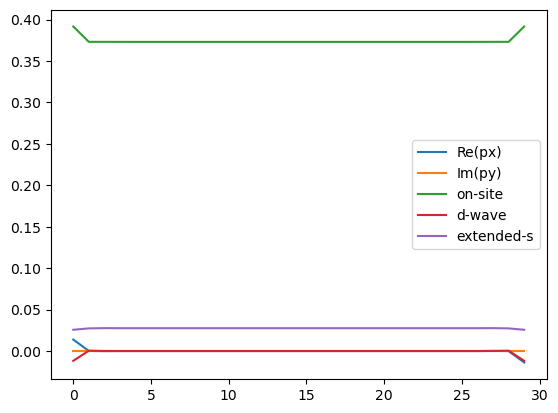

In [32]:
plt.plot(np.real(Fx_p - Fx_m)/2, label='Re(px)')
plt.plot(np.imag(F_yplus - F_ymin)/2, label='Im(py)')
plt.plot(np.abs(F0), label='on-site')
plt.plot(np.real(Fx_p + Fx_m - F_yplus - F_ymin)/4, label='d-wave')
plt.plot(np.real(Fx_p + Fx_m + F_yplus + F_ymin)/4, label='extended-s')
plt.legend()

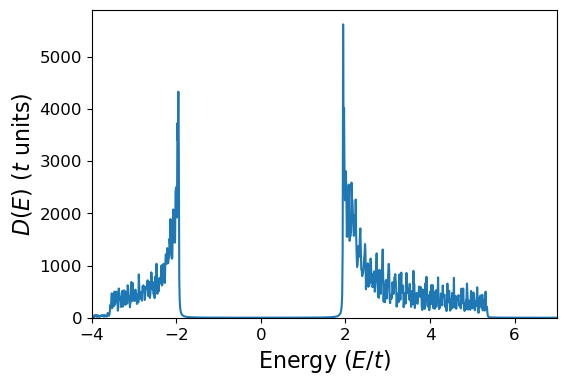

In [33]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.0051)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [12]:
print(H.free_energy(0))

-3296.3259560795027


In [13]:
# %prun H.dos(energies, eta=1e-3)